# PHÂN TÍCH DỮ LIỆU TUYỂN DỤNG IT TẠI VIỆT NAM 

## 1. Phát biểu bài toán

### Phát biểu bài toán theo yêu cầu đề bài
Phân tích dữ liệu nhằm khảo sát tính khả thi cho việc xây dựng mô hình từ các biến/đặc trưng `X_i` trên dữ liệu tuyển dụng IT do nhóm tự crawl.

Nếu biến mục tiêu `Y` được xác định cụ thể thì bài toán sẽ thuộc một trong hai hướng: **classification** nếu `Y` là biến danh mục, hoặc **regression** nếu `Y` là biến số thực. Tuy nhiên, trên bộ dữ liệu hiện tại, nhóm **chưa chọn một biến mục tiêu `Y` duy nhất để làm hướng chính** cho toàn bộ bài giữa kỳ vì dữ liệu lương bị thiếu khá nhiều. Do đó, bài toán chính được xem là **clustering**.

Nhóm đánh giá bài toán này **khả thi về mặt dữ liệu** vì bộ dữ liệu có quy mô đủ lớn, được tự thu thập, đã qua làm sạch và có tập đặc trưng tương đối rõ để mô tả vai trò công việc, level, địa điểm tuyển dụng và kỹ năng công nghệ.

Ngoài hướng phân cụm trên toàn bộ dữ liệu sạch, nhóm cũng xét thêm **tập con có lương** (`jobs_salary_subset.csv`) để xem khả năng mở rộng sang bài toán `regression` với biến mục tiêu `salary_avg`. Tuy nhiên, tập con này chỉ gồm các bản ghi có thông tin lương, nên quy mô nhỏ hơn khá nhiều so với toàn bộ dữ liệu sạch. Vì vậy, trong bài giữa kỳ, nhóm chỉ dùng phần này để tham khảo thêm, còn hướng chính vẫn là `clustering`.

Tập đặc trưng hữu ích được nhóm lựa chọn cho hướng phân cụm gồm: `job_title_group`, `level`, `experience_years`, `location`, `company_type`, `remote_option`, `skills_count`, `main_language`, `main_framework`, `skill_domain`, `requires_english` và các biến chỉ báo kỹ năng như `has_ai`, `has_python`, `has_java`, `has_js_ts`, `has_sql`, `has_cloud`, `has_data`, `has_devops`, `has_mobile`, `has_testing`, `has_backend`, `has_frontend`.

Đối với tập con có lương, các đặc trưng trên vẫn có thể dùng để khảo sát khả năng xây dựng mô hình hồi quy dự đoán `salary_avg`, nhưng do độ phủ dữ liệu lương thấp hơn nên nhóm không đặt phần này làm nội dung chính của notebook.

Phân tích dữ liệu nhằm khảo sát tính khả thi cho việc xây dựng mô hình từ các biến/đặc trưng `X_i` trên dữ liệu tuyển dụng IT do nhóm **tự crawl**.

Trên bộ dữ liệu hiện tại, nhóm **chưa chọn một biến mục tiêu `Y` duy nhất làm hướng chính** cho bài giữa kỳ. Lý do là thông tin lương chỉ xuất hiện trên một phần dữ liệu và bị thiếu nhiều, nên nếu lấy `salary_avg` làm mục tiêu chính thì quy mô mẫu dùng cho phân tích sẽ giảm khá nhiều.

Vì vậy, **hướng chính của notebook là bài toán phân cụm (clustering) / khám phá cấu trúc dữ liệu** trên không gian đặc trưng tuyển dụng, nhằm trả lời các câu hỏi:
- Bộ dữ liệu có đủ lớn, đủ sạch và đủ giàu đặc trưng để quan sát cấu trúc cụm hay không?
- Những nhóm đặc trưng nào là hữu ích nhất để biểu diễn thị trường tuyển dụng IT?
- Có quan sát được các cụm tiềm ẩn theo `job_title_group`, `level`, `location`, `remote_option`, `company_type`, `skills_extracted` hay không?

**Lưu ý:** phần `salary regression` chỉ được xem là **hướng mở rộng phụ** trên tập con `jobs_salary_subset.csv` gồm các bản ghi có lương, không phải trọng tâm của bài giữa kỳ.


### Kết luận định hướng ngay từ đầu
- **Bài toán chính:** `clustering` / exploratory analysis trên dữ liệu tuyển dụng IT.
- **Bài toán phụ (không trọng tâm):** `regression` trên `salary_avg` với tập con có lương.
- **Tính khả thi về dữ liệu cho clustering:** cao hơn regression, vì có thể tận dụng gần như toàn bộ dữ liệu sạch thay vì chỉ dùng tập con có lương.


In [1]:
from pathlib import Path
import warnings
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.manifold import TSNE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from src.processing.clean_jobs import (
    normalize_location,
    normalize_remote_option,
    parse_experience_years,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 11

BASE_DIR = Path('.')
RAW_ITVIEC = BASE_DIR / 'data/raw/itviec_jobs_20260316_190527.csv'
RAW_TOPCV = BASE_DIR / 'data/raw/topcv_jobs_20260316_205315.csv'
CLEAN_PATH = BASE_DIR / 'data/clean-data/jobs_cleaned.csv'
FEATURE_PATH = BASE_DIR / 'data/clean-data/jobs_features.csv'
SALARY_SUBSET_PATH = BASE_DIR / 'data/clean-data/jobs_salary_subset.csv'

df_itviec = pd.read_csv(RAW_ITVIEC)
df_topcv = pd.read_csv(RAW_TOPCV)
df_raw_merged = pd.concat(
    [df_itviec.assign(source='itviec'), df_topcv.assign(source='topcv')],
    ignore_index=True,
)
df_clean = pd.read_csv(CLEAN_PATH)
df_features = pd.read_csv(FEATURE_PATH)
df_salary = pd.read_csv(SALARY_SUBSET_PATH)

summary_loaded = pd.DataFrame(
    {
        'dataset': ['ITViec raw', 'TopCV raw', 'jobs_cleaned', 'jobs_features', 'jobs_salary_subset'],
        'rows': [len(df_itviec), len(df_topcv), len(df_clean), len(df_features), len(df_salary)],
        'columns': [
            df_itviec.shape[1],
            df_topcv.shape[1],
            df_clean.shape[1],
            df_features.shape[1],
            df_salary.shape[1],
        ],
        'path': [
            str(RAW_ITVIEC),
            str(RAW_TOPCV),
            str(CLEAN_PATH),
            str(FEATURE_PATH),
            str(SALARY_SUBSET_PATH),
        ],
    }
)
summary_loaded


,dataset,rows,columns,path
0,ITViec raw,997,13,data/raw/itviec_jobs_20260316_190527.csv
1,TopCV raw,418,12,data/raw/topcv_jobs_20260316_205315.csv
2,jobs_cleaned,1393,40,data/clean-data/jobs_cleaned.csv
3,jobs_features,1393,58,data/clean-data/jobs_features.csv
4,jobs_salary_subset,527,40,data/clean-data/jobs_salary_subset.csv


## 2. Thu thập dữ liệu
Theo yêu cầu học phần, nhóm phải **tự thu thập dữ liệu**, không được dùng dataset tải sẵn. Trong project hiện tại, dữ liệu được crawl từ hai nguồn đang có thật trong thư mục `data/raw/`:
- `ITViec`: dữ liệu thiên về các vị trí kỹ thuật, nhiều thông tin mô tả và company metadata hơn.
- `TopCV`: dữ liệu bổ sung thêm số lượng tin và độ phủ về vị trí tuyển dụng.

Hai script crawl hiện có:
- `src/data_collection/itviec_crawler.py`
- `src/data_collection/topcv_crawler.py`

Dữ liệu raw thực tế hiện có:
- `ITViec`: `997` mẫu, `13` biến.
- `TopCV`: `418` mẫu, `12` biến.
- **Tổng raw:** `1415` mẫu, vượt yêu cầu `>1000` mẫu.


In [2]:
collection_summary = pd.DataFrame(
    {
        'Nguồn': ['ITViec', 'TopCV', 'Tổng cộng'],
        'File raw': [RAW_ITVIEC.name, RAW_TOPCV.name, '-'],
        'Script crawl': [
            'src/data_collection/itviec_crawler.py',
            'src/data_collection/topcv_crawler.py',
            '-',
        ],
        'Cách thu thập': [
            'Selenium + BeautifulSoup, crawl từ listing rồi vào trang chi tiết',
            'Selenium + BeautifulSoup, crawl listing và trang chi tiết',
            'Dữ liệu do nhóm tự crawl từ 2 nguồn',
        ],
        'Số mẫu raw': [len(df_itviec), len(df_topcv), len(df_raw_merged)],
        'Số biến raw': [df_itviec.shape[1], df_topcv.shape[1], df_raw_merged.shape[1]],
    }
)
collection_summary


,Nguồn,File raw,Script crawl,Cách thu thập,Số mẫu raw,Số biến raw
0,ITViec,itviec_jobs_20260316_190527.csv,src/data_collection/itviec_crawler.py,"Selenium + BeautifulSoup, crawl từ listing rồi...",997,13
1,TopCV,topcv_jobs_20260316_205315.csv,src/data_collection/topcv_crawler.py,"Selenium + BeautifulSoup, crawl listing và tra...",418,12
2,Tổng cộng,-,-,Dữ liệu do nhóm tự crawl từ 2 nguồn,1415,15


### Schema dữ liệu raw
Các trường raw nổi bật đang có gồm:
- `job_title`
- `tech_stack`
- `experience_years`
- `location`
- `company_name`
- `remote_option`
- `salary_min`, `salary_max`, `currency`
- `posted_date`, `deadline`
- `job_description`

Số biến raw đều lớn hơn `5`, thỏa yêu cầu đề bài.


In [3]:
print('Các cột của ITViec:', list(df_itviec.columns))
print('Các cột của TopCV :', list(df_topcv.columns))

display(df_itviec.head(3))
display(df_topcv.head(3))


Các cột của ITViec: ['job_title', 'tech_stack', 'experience_years', 'location', 'company_name', 'company_type', 'company_industry', 'remote_option', 'salary_min', 'salary_max', 'currency', 'posted_date', 'job_description']
Các cột của TopCV : ['job_title', 'tech_stack', 'experience_years', 'location', 'company_name', 'remote_option', 'salary_min', 'salary_max', 'currency', 'posted_date', 'deadline', 'job_description']


,job_title,tech_stack,experience_years,location,company_name,company_type,company_industry,remote_option,salary_min,salary_max,currency,posted_date,job_description
0,Scrum Master/ Scrum Coach,"Scrum, Project Management, Agile, Less, Jira",2 years,Ha Noi,One Mount Group,IT Service and IT Consulting,IT Services and IT Consulting,onsite,NaN,NaN,NaN,3/16/2026,Job description The Senior Scrum Master/ Scrum...
1,Senior Automation Tester,"Automation Test, Java",NaN,Ho Chi Minh,Capgemini Vietnam,IT Service and IT Consulting,IT Services and IT Consulting,onsite,NaN,NaN,NaN,3/16/2026,Job description Participate in agile practices...
2,Senior/ Principal Android Engineer (Kotlin),"Android, MVVM, Clean Architecture, Kotlin, AWS...",7+ years,Ho Chi Minh,"ANDPAD VietNam Co., Ltd",IT Product,Software Products and Web Services,hybrid,NaN,NaN,NaN,3/16/2026,Job description ANDPAD Viet Nam is looking for...


,job_title,tech_stack,experience_years,location,company_name,remote_option,salary_min,salary_max,currency,posted_date,deadline,job_description
0,"Java Developer (Mid/Senior), 20M – 45M VND","Backend Developer, IT - Phần mềm",2.0,Hà Nội,CÔNG TY TNHH SOFTROAD,onsite,20000000.0,45000000.0,VND,3/12/2026,27/03/2026,Perform coding and debugging tasks.\nConduct s...
1,SAP/ ERP Sales Executive (HN/HCM),"Kinh doanh phần mềm, IT - Phần mềm, B2B, Direc...",3.0,Hồ Chí Minh,CÔNG TY CỔ PHẦN CÔNG NGHỆ CITEK,onsite,NaN,NaN,NaN,NaN,30/04/2026,"JOB DESCRIPTION\nJob Overview:\nAt Citek, we a..."
2,Junior Fullstack Developer (NODE.JS + REACT) (...,"Fullstack Developer, IT - Phần mềm",2.0,Hà Nội,CÔNG TY CỔ PHẦN GIẢI PHÁP CÔNG NGHỆ ZENIFY,onsite,25000000.0,25000000.0,VND,3/2/2026,30/04/2026,Chúng tôi đang xây dựng nền tảng SaaS Contact ...


## 3. Mô tả dữ liệu ban đầu
Mục tiêu của phần này là xác định dữ liệu có đủ tốt cho phân tích cụm hay không thông qua:
- quy mô mẫu;
- mức độ thiếu dữ liệu;
- độ phong phú của các biến mô tả nghề nghiệp, địa lý, level và kỹ năng.

Kết quả thực tế sau pipeline:
- `jobs_cleaned.csv`: `1393` mẫu.
- `jobs_features.csv`: `1393` mẫu.
- `jobs_salary_subset.csv`: `527` mẫu có lương.

Điều này cho thấy nếu theo hướng `clustering`, nhóm có thể tận dụng gần như toàn bộ tập dữ liệu sạch; còn nếu theo `regression`, chỉ dùng được khoảng `527 / 1393` mẫu.


In [4]:
raw_overview = pd.DataFrame(
    {
        'Chỉ số': [
            'Số mẫu raw sau khi gộp',
            'Số nguồn dữ liệu',
            'Số biến raw sau khi gộp',
            'Số mẫu clean',
            'Số mẫu feature-ready',
            'Số mẫu có salary',
            'Tỷ lệ có salary',
        ],
        'Giá trị': [
            len(df_raw_merged),
            df_raw_merged['source'].nunique(),
            df_raw_merged.shape[1],
            len(df_clean),
            len(df_features),
            len(df_salary),
            round(len(df_salary) / len(df_clean), 4),
        ],
    }
)
missing_ratio_raw = df_raw_merged.isna().mean().sort_values(ascending=False).rename('Tỷ lệ thiếu raw').to_frame()
missing_ratio_clean = df_clean.isna().mean().sort_values(ascending=False).rename('Tỷ lệ thiếu clean').to_frame()

display(raw_overview)
display(missing_ratio_raw.head(10))
display(missing_ratio_clean.head(10))


,Chỉ số,Giá trị
0,Số mẫu raw sau khi gộp,1415.0000
1,Số nguồn dữ liệu,2.0000
2,Số biến raw sau khi gộp,15.0000
3,Số mẫu clean,1393.0000
4,Số mẫu feature-ready,1393.0000
5,Số mẫu có salary,527.0000
6,Tỷ lệ có salary,0.3783


,Tỷ lệ thiếu raw
deadline,0.704594
salary_min,0.620495
salary_max,0.620495
currency,0.620495
company_industry,0.305300
company_type,0.295406
experience_years,0.147703
posted_date,0.000707
job_title,0.000000
tech_stack,0.000000


,Tỷ lệ thiếu clean
deadline,0.709261
primary_language_hint,0.687724
salary_min,0.621680
salary_max,0.621680
salary_band,0.621680
salary_min_original,0.621680
salary_max_original,0.621680
currency_original,0.621680
salary_currency,0.621680
salary_avg,0.621680


## 4. Thống kê mô tả và trực quan hóa đơn biến
Để phục vụ clustering, các biến quan trọng nhất là:
- `job_title_group`
- `level`
- `location`
- `company_type`
- `remote_option`
- `source`
- `skills_extracted`
- `skills_count`

Đây là các biến phản ánh cấu trúc nghề nghiệp và công nghệ của từng tin tuyển dụng.


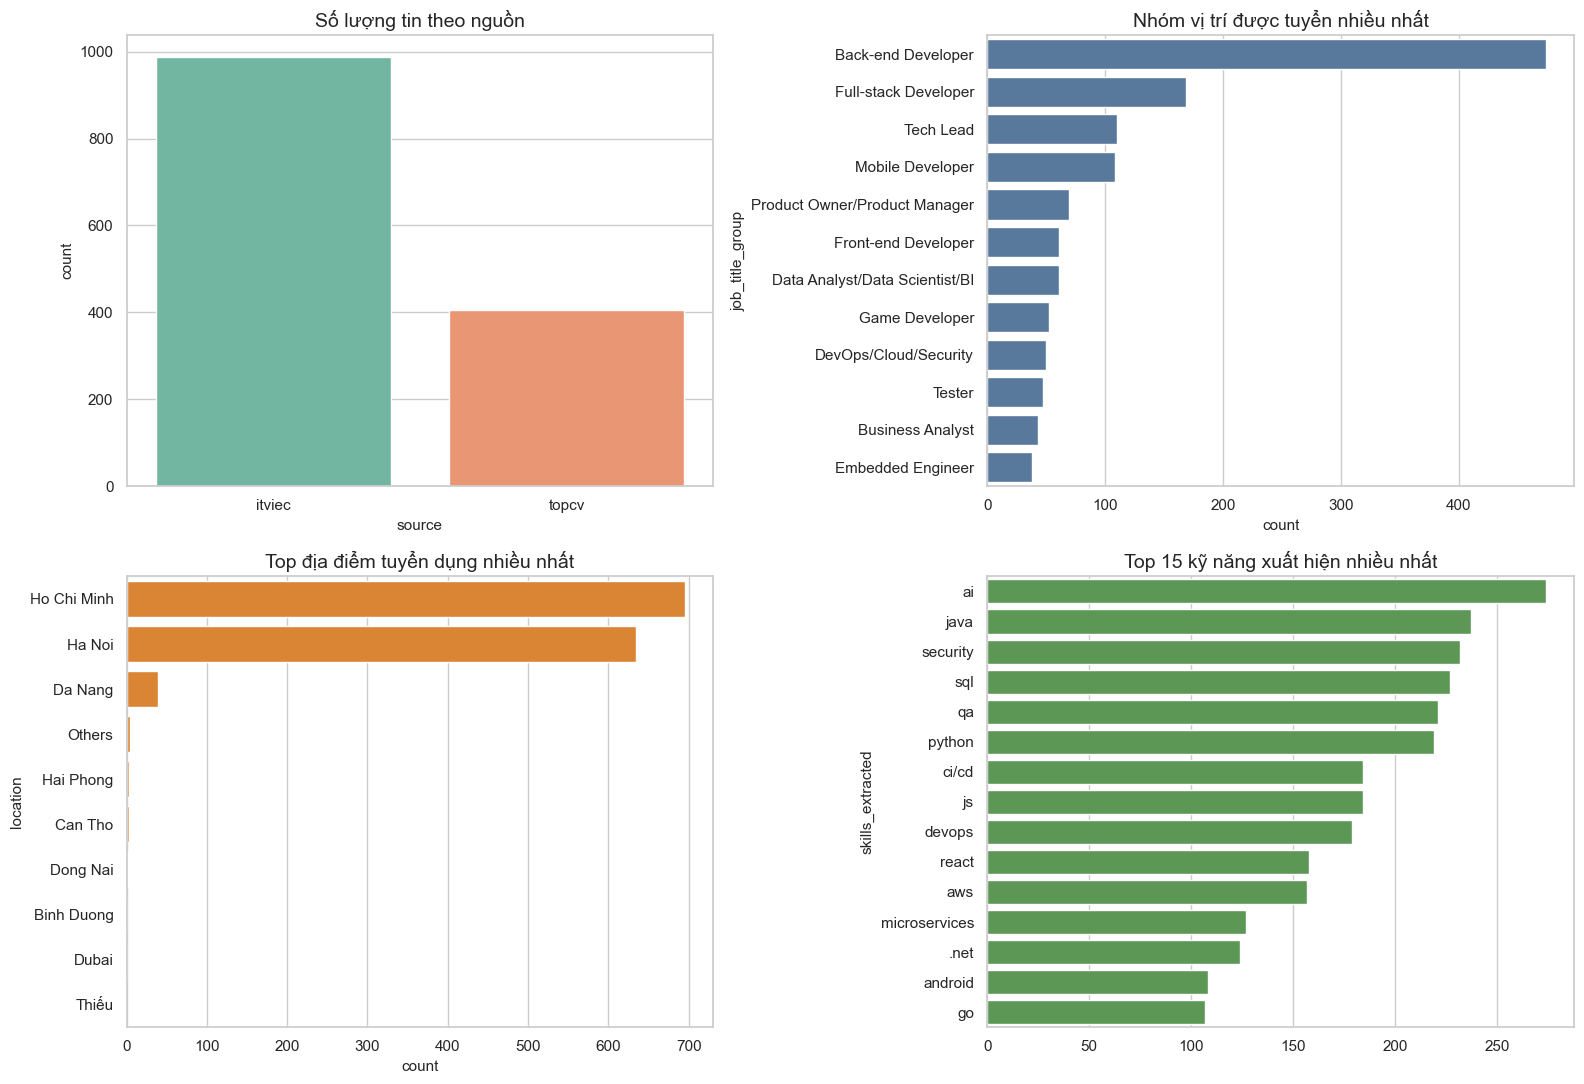

In [5]:
source_counts = df_clean['source'].value_counts()
top_locations = df_clean['location'].fillna('Thiếu').value_counts().head(10)
top_levels = df_clean['level'].fillna('Thiếu').value_counts()
top_roles = df_clean['job_title_group'].fillna('Thiếu').value_counts().head(12)
top_company_types = df_clean['company_type'].fillna('Thiếu').value_counts()

skill_freq = (
    df_features['skills_extracted']
    .fillna('')
    .str.split(', ')
    .explode()
)
skill_freq = skill_freq[skill_freq.ne('')].value_counts().head(15)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.countplot(data=df_clean, x='source', order=source_counts.index, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Số lượng tin theo nguồn')

sns.countplot(data=df_clean, y='job_title_group', order=top_roles.index, ax=axes[0, 1], color='#4c78a8')
axes[0, 1].set_title('Nhóm vị trí được tuyển nhiều nhất')

sns.countplot(data=df_clean, y='location', order=top_locations.index, ax=axes[1, 0], color='#f58518')
axes[1, 0].set_title('Top địa điểm tuyển dụng nhiều nhất')

sns.barplot(x=skill_freq.values, y=skill_freq.index, ax=axes[1, 1], color='#54a24b')
axes[1, 1].set_title('Top 15 kỹ năng xuất hiện nhiều nhất')

plt.tight_layout()
plt.show()


### Nhận xét chi tiết từ các biểu đồ đơn biến
- Về **nhóm vị trí tuyển dụng**, `Back-end Developer` xuất hiện nhiều nhất với `474` tin, cao hơn khá nhiều so với `Full-stack Developer` (`169` tin). Từ đó có thể thấy trong bộ dữ liệu hiện tại, nhu cầu tuyển backend đang chiếm phần lớn. Ngoài ra, `Tech Lead` (`110` tin) và `Mobile Developer` (`108` tin) cũng xuất hiện khá nhiều.
- Về **địa lý tuyển dụng**, `Ho Chi Minh` (`696` tin) và `Ha Noi` (`635` tin) chiếm gần như toàn bộ số lượng tin tuyển dụng. `Da Nang` chỉ có `39` tin, còn các địa phương khác rất ít. Có thể nhận xét rằng dữ liệu của nhóm đang tập trung chủ yếu ở hai trung tâm tuyển dụng IT lớn nhất.
- Về **cấp bậc tuyển dụng**, ba nhóm `Junior` (`365` tin), `Middle` (`367` tin) và `Senior` (`357` tin) khá cân bằng nhau. Điều này cho thấy doanh nghiệp đang tuyển ở nhiều mức kinh nghiệm khác nhau, không chỉ tập trung vào một level duy nhất.
- Về **kỹ năng**, các skill xuất hiện nhiều gồm `ai` (`274`), `java` (`237`), `security` (`232`), `sql` (`227`), `qa` (`221`) và `python` (`219`). Nhìn chung, ngoài các skill lập trình quen thuộc thì các nhóm `AI/Data`, `Security` và `Testing` cũng xuất hiện khá rõ.
- Từ các biểu đồ đơn biến, nhóm thấy dữ liệu có sự khác biệt khá rõ theo vị trí, địa điểm và kỹ năng. Đây là cơ sở tốt để đi tiếp sang phần phân tích đa biến và kiểm tra khả năng phân cụm.


## 5. Làm sạch và chuẩn hóa dữ liệu
Cleaning là bước then chốt để tránh tạo ra các cụm giả do nhãn không đồng nhất. Trong project hiện tại, cleaning tập trung vào:
- chuẩn hóa `location`;
- chuẩn hóa `remote_option`;
- chuẩn hóa `experience_years`;
- tạo `job_title_group`, `level`, `company_type`;
- loại bỏ trùng lặp và chọn bản ghi chất lượng hơn.

Với clustering, bước này đặc biệt quan trọng vì khoảng cách giữa các điểm dữ liệu sẽ bị méo nếu các nhãn cùng nghĩa chưa được gộp lại.


,Chỉ số,Giá trị
0,Số mẫu raw sau khi gộp,1415
1,Số mẫu sau cleaning,1393
2,Số mẫu bị loại,22
3,Số nhãn location khác nhau trước cleaning,24
4,Số nhãn location khác nhau sau cleaning,18
5,Số nhãn remote_option khác nhau trước cleaning,3
6,Số nhãn remote_option khác nhau sau cleaning,3
7,Số nhóm vị trí sau chuẩn hóa,19


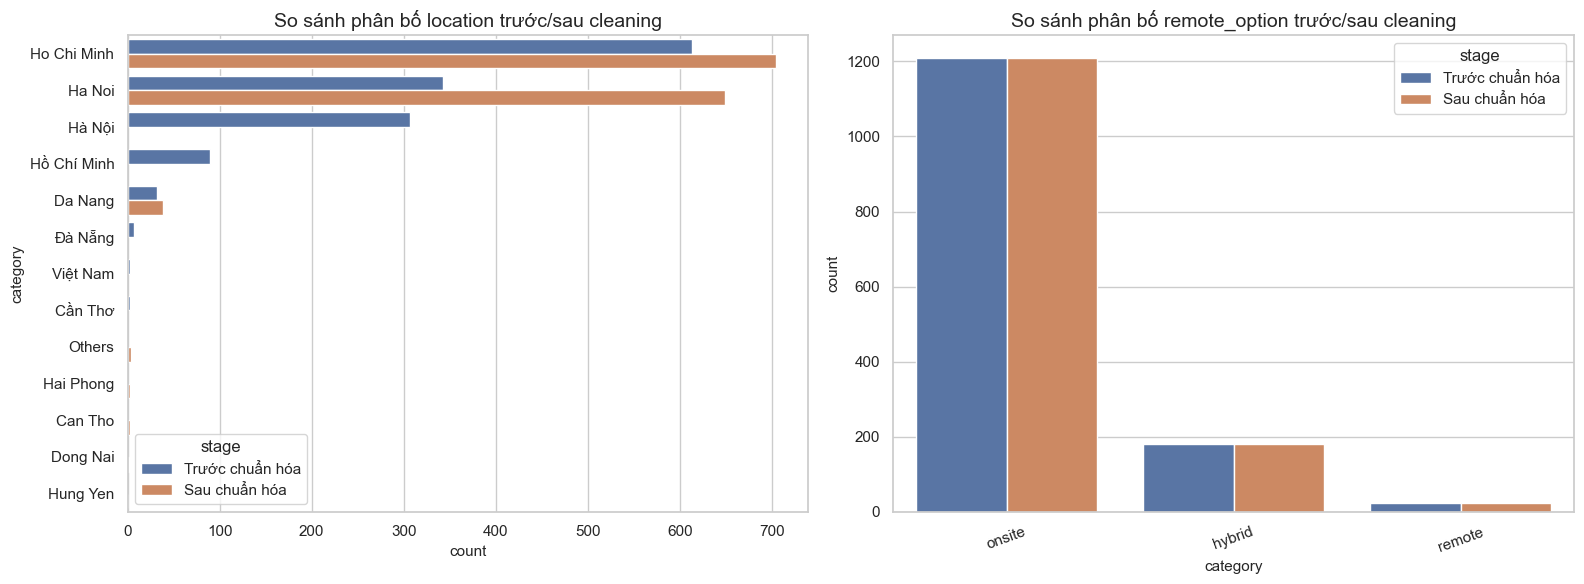

,experience_raw,experience_parsed
0,2 years,2.0
1,NaN,NaN
2,7+ years,7.0
3,NaN,NaN
4,7+ years,7.0
5,8+ years,8.0
6,02+ years,2.0
7,3 years,3.0
8,3-5 years,4.0
9,NaN,NaN


In [6]:
location_before = df_raw_merged['location'].fillna('Thiếu')
location_after = df_raw_merged['location'].apply(normalize_location).fillna('Thiếu')
remote_before = df_raw_merged['remote_option'].fillna('Thiếu')
remote_after = df_raw_merged['remote_option'].apply(normalize_remote_option).fillna('Thiếu')
experience_after = df_raw_merged['experience_years'].apply(parse_experience_years)

cleaning_summary = pd.DataFrame(
    {
        'Chỉ số': [
            'Số mẫu raw sau khi gộp',
            'Số mẫu sau cleaning',
            'Số mẫu bị loại',
            'Số nhãn location khác nhau trước cleaning',
            'Số nhãn location khác nhau sau cleaning',
            'Số nhãn remote_option khác nhau trước cleaning',
            'Số nhãn remote_option khác nhau sau cleaning',
            'Số nhóm vị trí sau chuẩn hóa',
        ],
        'Giá trị': [
            len(df_raw_merged),
            len(df_clean),
            len(df_raw_merged) - len(df_clean),
            location_before.nunique(dropna=True),
            location_after.nunique(dropna=True),
            remote_before.nunique(dropna=True),
            remote_after.nunique(dropna=True),
            df_clean['job_title_group'].nunique(dropna=True),
        ],
    }
)
display(cleaning_summary)

location_compare = pd.concat(
    [
        location_before.value_counts().head(8).rename_axis('category').reset_index(name='count').assign(stage='Trước chuẩn hóa'),
        location_after.value_counts().head(8).rename_axis('category').reset_index(name='count').assign(stage='Sau chuẩn hóa'),
    ],
    ignore_index=True,
)

remote_compare = pd.concat(
    [
        remote_before.value_counts().rename_axis('category').reset_index(name='count').assign(stage='Trước chuẩn hóa'),
        remote_after.value_counts().rename_axis('category').reset_index(name='count').assign(stage='Sau chuẩn hóa'),
    ],
    ignore_index=True,
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=location_compare, x='count', y='category', hue='stage', ax=axes[0])
axes[0].set_title('So sánh phân bố location trước/sau cleaning')

sns.barplot(data=remote_compare, x='category', y='count', hue='stage', ax=axes[1])
axes[1].set_title('So sánh phân bố remote_option trước/sau cleaning')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

display(pd.DataFrame({'experience_raw': df_raw_merged['experience_years'].head(10), 'experience_parsed': experience_after.head(10)}))


## 7. Xây dựng và lựa chọn đặc trưng
Với hướng clustering, nhóm không đưa toàn bộ cột trong `jobs_features.csv` vào mô hình, mà chỉ chọn những đặc trưng có khả năng mô tả **cấu trúc nghề nghiệp**, **seniority**, **bối cảnh tuyển dụng** và **cụm kỹ năng công nghệ**.

Tập đặc trưng được chọn chính thức cho phân tích/clustering là:
- `job_title_group`
- `level`
- `experience_years`
- `location`
- `company_type`
- `remote_option`
- `skills_count`
- `main_language`
- `main_framework`
- `skill_domain`
- `requires_english`
- `has_ai`
- `has_python`
- `has_java`
- `has_js_ts`
- `has_sql`
- `has_cloud`
- `has_data`
- `has_devops`
- `has_mobile`
- `has_testing`
- `has_backend`
- `has_frontend`

Lý do chọn nhóm đặc trưng này:
- Chúng biểu diễn trực tiếp vai trò công việc, cấp bậc, bối cảnh địa lý và hình thức làm việc.
- Chúng phản ánh được cụm công nghệ thông qua skill indicators thay vì phụ thuộc vào text thô.
- Chúng đã được chuẩn hóa tốt hơn so với các cột raw như `tech_stack`, `job_description`, `job_title_raw`.
- Chúng phù hợp với one-hot encoding hoặc giữ ở dạng numeric/binary để đưa vào không gian đặc trưng cho clustering.

Về mặt feature engineering, đây là tập đặc trưng hợp lý hơn so với việc dùng trực tiếp các trường raw hoặc lấy `salary_avg` làm trung tâm, vì mục tiêu chính của bài giữa kỳ là đánh giá tính khả thi dữ liệu cho phân tích cấu trúc và phân cụm.


In [7]:
selected_features = pd.DataFrame(
    [
        ['job_title_group', 'category', 'Nhóm vai trò công việc', 'Giữ lại', 'Biến đại diện tốt cho cụm nghề nghiệp'],
        ['level', 'category', 'Cấp bậc tuyển dụng', 'Giữ lại', 'Phản ánh seniority của vị trí'],
        ['experience_years', 'numeric', 'Số năm kinh nghiệm', 'Giữ lại', 'Bổ sung thông tin định lượng cho level'],
        ['location', 'category', 'Địa điểm tuyển dụng đã chuẩn hóa', 'Giữ lại', 'Giúp tách cụm theo trung tâm tuyển dụng'],
        ['company_type', 'category', 'Loại hình doanh nghiệp', 'Giữ lại', 'Có thể liên hệ với nhu cầu kỹ năng và cách tuyển dụng'],
        ['remote_option', 'category', 'Hình thức làm việc', 'Giữ lại', 'Phân biệt onsite/hybrid/remote'],
        ['skills_count', 'numeric', 'Số lượng kỹ năng trích xuất', 'Giữ lại', 'Phản ánh độ rộng yêu cầu kỹ năng'],
        ['main_language', 'category', 'Ngôn ngữ lập trình nổi bật', 'Giữ lại', 'Tóm tắt trục công nghệ chính'],
        ['main_framework', 'category', 'Framework/công nghệ nổi bật', 'Giữ lại', 'Hữu ích để phân biệt nhóm frontend/backend/mobile'],
        ['skill_domain', 'category', 'Miền kỹ năng chính', 'Giữ lại', 'Tóm tắt domain kỹ thuật ở mức cao'],
        ['requires_english', 'binary', 'Có yêu cầu tiếng Anh', 'Giữ lại', 'Bổ sung tín hiệu về bối cảnh công việc và doanh nghiệp'],
        ['has_ai', 'binary', 'Có skill AI/ML/LLM', 'Giữ lại', 'Tách cụm Data/AI'],
        ['has_python', 'binary', 'Có Python', 'Giữ lại', 'Ngôn ngữ phổ biến cho backend/data/automation'],
        ['has_java', 'binary', 'Có Java', 'Giữ lại', 'Quan trọng cho backend enterprise'],
        ['has_js_ts', 'binary', 'Có JS/TS hoặc hệ sinh thái liên quan', 'Giữ lại', 'Rất mạnh để phân biệt web/frontend/fullstack'],
        ['has_sql', 'binary', 'Có SQL/DB', 'Giữ lại', 'Hữu ích cho backend/data/BI'],
        ['has_cloud', 'binary', 'Có cloud', 'Giữ lại', 'Hữu ích cho cloud/platform'],
        ['has_data', 'binary', 'Có data stack', 'Giữ lại', 'Tách cụm data'],
        ['has_devops', 'binary', 'Có DevOps', 'Giữ lại', 'Tách cụm hạ tầng/platform'],
        ['has_mobile', 'binary', 'Có mobile stack', 'Giữ lại', 'Tách cụm mobile'],
        ['has_testing', 'binary', 'Có testing/QA', 'Giữ lại', 'Tách cụm kiểm thử'],
        ['has_backend', 'binary', 'Nghiêng backend', 'Giữ lại', 'Tóm tắt orientation kỹ thuật'],
        ['has_frontend', 'binary', 'Nghiêng frontend', 'Giữ lại', 'Tóm tắt orientation kỹ thuật'],
    ],
    columns=['Đặc trưng', 'Kiểu dữ liệu', 'Ý nghĩa', 'Quyết định', 'Lý do'],
)

excluded_features = pd.DataFrame(
    [
        ['job_id', 'identifier', 'Không giữ', 'Chỉ là mã định danh, không mang ý nghĩa cụm'],
        ['company_name', 'high-cardinality category', 'Không giữ', 'Quá nhiều giá trị riêng lẻ, dễ gây phân mảnh cụm'],
        ['job_title', 'raw text', 'Không giữ trực tiếp', 'Quá chi tiết và nhiều biến thể; đã được rút gọn qua job_title_group'],
        ['job_title_raw', 'raw text', 'Không giữ', 'Trùng vai trò với job_title và còn nhiễu'],
        ['job_description', 'long raw text', 'Không giữ trực tiếp', 'Đã được trích lọc thành skills_extracted, requires_english và các skill indicators'],
        ['tech_stack', 'semi-raw text', 'Không giữ trực tiếp', 'Chưa đủ sạch để dùng như feature cuối; được dùng làm nguồn trích skill'],
        ['skills_extracted', 'text/list', 'Không giữ trực tiếp', 'Danh sách text khó đưa trực tiếp vào clustering nếu không vector hóa; đã tóm tắt qua skills_count, main_language và has_*'],
        ['primary_city', 'category', 'Không giữ', 'Nội dung gần trùng với location'],
        ['location_bucket', 'category', 'Không giữ', 'Khái quát hơn location, có thể làm mất chi tiết hữu ích'],
        ['source', 'category', 'Không giữ', 'Dễ phản ánh nguồn crawl hơn là cấu trúc nghề nghiệp thật'],
        ['experience_band', 'category', 'Không giữ', 'Trùng ý nghĩa với experience_years và level'],
        ['company_type_inferred', 'category', 'Không giữ', 'Gần trùng với company_type'],
        ['salary_min, salary_max, salary_avg', 'numeric', 'Không giữ cho clustering chính', 'Lương thiếu nhiều và chỉ phù hợp cho nhánh regression phụ'],
        ['salary_band, has_salary', 'derived salary', 'Không giữ', 'Mang thiên hướng bài toán lương, không phải trọng tâm clustering'],
        ['posted_date, deadline, crawl_date', 'time', 'Không giữ', 'Chưa được chuẩn hóa thêm thành đặc trưng thời gian có ý nghĩa'],
        ['location_raw, remote_option_raw, experience_raw', 'raw columns', 'Không giữ', 'Chỉ phục vụ kiểm tra cleaning'],
        ['salary_min_original, salary_max_original, currency_original, currency', 'raw salary columns', 'Không giữ', 'Chỉ phục vụ chuẩn hóa dữ liệu lương'],
        ['primary_language_hint', 'heuristic', 'Không giữ', 'Thông tin yếu hơn main_language đã được trích xuất từ skill set'],
    ],
    columns=['Biến không chọn', 'Kiểu dữ liệu', 'Quyết định', 'Lý do'],
)

display(selected_features)
display(excluded_features)


,Đặc trưng,Kiểu dữ liệu,Ý nghĩa,Quyết định,Lý do
0,job_title_group,category,Nhóm vai trò công việc,Giữ lại,Biến đại diện tốt cho cụm nghề nghiệp
1,level,category,Cấp bậc tuyển dụng,Giữ lại,Phản ánh seniority của vị trí
2,experience_years,numeric,Số năm kinh nghiệm,Giữ lại,Bổ sung thông tin định lượng cho level
3,location,category,Địa điểm tuyển dụng đã chuẩn hóa,Giữ lại,Giúp tách cụm theo trung tâm tuyển dụng
4,company_type,category,Loại hình doanh nghiệp,Giữ lại,Có thể liên hệ với nhu cầu kỹ năng và cách tuy...
5,remote_option,category,Hình thức làm việc,Giữ lại,Phân biệt onsite/hybrid/remote
6,skills_count,numeric,Số lượng kỹ năng trích xuất,Giữ lại,Phản ánh độ rộng yêu cầu kỹ năng
7,main_language,category,Ngôn ngữ lập trình nổi bật,Giữ lại,Tóm tắt trục công nghệ chính
8,main_framework,category,Framework/công nghệ nổi bật,Giữ lại,Hữu ích để phân biệt nhóm frontend/backend/mobile
9,skill_domain,category,Miền kỹ năng chính,Giữ lại,Tóm tắt domain kỹ thuật ở mức cao


,Biến không chọn,Kiểu dữ liệu,Quyết định,Lý do
0,job_id,identifier,Không giữ,"Chỉ là mã định danh, không mang ý nghĩa cụm"
1,company_name,high-cardinality category,Không giữ,"Quá nhiều giá trị riêng lẻ, dễ gây phân mảnh cụm"
2,job_title,raw text,Không giữ trực tiếp,Quá chi tiết và nhiều biến thể; đã được rút gọ...
3,job_title_raw,raw text,Không giữ,Trùng vai trò với job_title và còn nhiễu
4,job_description,long raw text,Không giữ trực tiếp,"Đã được trích lọc thành skills_extracted, requ..."
5,tech_stack,semi-raw text,Không giữ trực tiếp,Chưa đủ sạch để dùng như feature cuối; được dù...
6,skills_extracted,text/list,Không giữ trực tiếp,Danh sách text khó đưa trực tiếp vào clusterin...
7,primary_city,category,Không giữ,Nội dung gần trùng với location
8,location_bucket,category,Không giữ,"Khái quát hơn location, có thể làm mất chi tiế..."
9,source,category,Không giữ,Dễ phản ánh nguồn crawl hơn là cấu trúc nghề n...


### Giải thích các biến không chọn
Các biến không được chọn không có nghĩa là vô ích. Phần lớn chúng vẫn quan trọng trong pipeline, nhưng chỉ đóng vai trò **nguồn để tạo feature** hoặc **phục vụ cleaning/QA**.

Cụ thể:
- `tech_stack`, `job_description`, `job_title` là nguồn text đầu vào để trích ra `main_language`, `main_framework`, `requires_english`, `skills_count` và các biến `has_*`.
- Các cột raw như `location_raw`, `experience_raw`, `remote_option_raw` chỉ có ý nghĩa ở bước chuẩn hóa dữ liệu.
- Các cột lương như `salary_avg`, `salary_band`, `has_salary` chỉ phù hợp cho bài toán phụ về regression, không nên đưa vào clustering chính vì độ phủ thấp hơn rõ rệt.
- Các biến định danh hoặc có số lượng giá trị riêng lẻ quá lớn như `job_id`, `company_name` sẽ làm mô hình học ra nhiễu thay vì cấu trúc chung.

Vì vậy, notebook chọn cách giữ lại các feature đã được chuẩn hóa và trích lọc, thay vì đưa trực tiếp toàn bộ cột gốc vào không gian phân cụm.


## 8. Trực quan hóa mối quan hệ đa biến
Mục tiêu của phần này là tìm ra sự tương tác giữa các nhóm biến như **kỹ năng - kinh nghiệm - loại hình công ty - level - location** để đánh giá xem dữ liệu có cấu trúc đủ rõ cho clustering hay không.

Theo hướng trình bày chuyên nghiệp hơn, phần trực quan hóa không chỉ dừng ở việc hiển thị đủ biến, mà còn phải giúp người xem nhận ra **các hệ sinh thái kỹ năng** và **các mối quan hệ thực sự có ý nghĩa**. Vì vậy, notebook ưu tiên:
- làm sạch nhãn từ tên biến kỹ thuật sang nhãn dễ đọc bằng tiếng Việt;
- dùng **Spearman correlation** cho biến số và biến nhị phân;
- làm nổi bật các tương quan đáng chú ý thay vì để ma trận bị loãng bởi các giá trị quá nhỏ;
- dùng **clustermap** để tự động gom nhóm các kỹ năng có xu hướng đi cùng nhau.


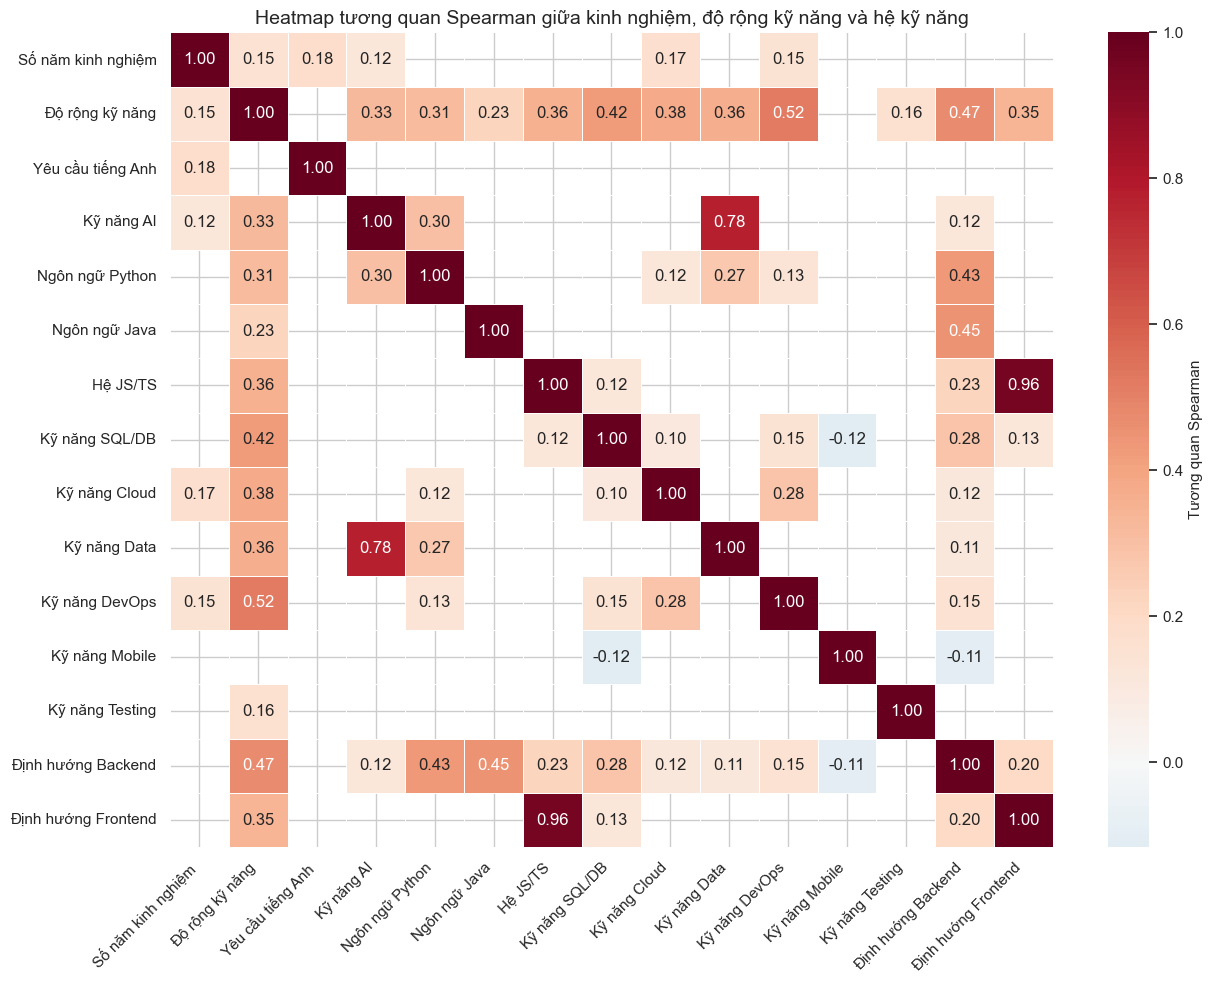

In [8]:
multivar_features = [
    'experience_years', 'skills_count', 'requires_english',
    'has_ai', 'has_python', 'has_java', 'has_js_ts', 'has_sql',
    'has_cloud', 'has_data', 'has_devops', 'has_mobile',
    'has_testing', 'has_backend', 'has_frontend'
]

feature_label_map = {
    'experience_years': 'Số năm kinh nghiệm',
    'skills_count': 'Độ rộng kỹ năng',
    'requires_english': 'Yêu cầu tiếng Anh',
    'has_ai': 'Kỹ năng AI',
    'has_python': 'Ngôn ngữ Python',
    'has_java': 'Ngôn ngữ Java',
    'has_js_ts': 'Hệ JS/TS',
    'has_sql': 'Kỹ năng SQL/DB',
    'has_cloud': 'Kỹ năng Cloud',
    'has_data': 'Kỹ năng Data',
    'has_devops': 'Kỹ năng DevOps',
    'has_mobile': 'Kỹ năng Mobile',
    'has_testing': 'Kỹ năng Testing',
    'has_backend': 'Định hướng Backend',
    'has_frontend': 'Định hướng Frontend',
}

corr_df = df_features[multivar_features].copy()
corr_matrix = corr_df.corr(method='spearman')
corr_matrix_named = corr_matrix.rename(index=feature_label_map, columns=feature_label_map)

heatmap_threshold = 0.10
plot_matrix = corr_matrix_named.copy()
mask_small = (plot_matrix.abs() < heatmap_threshold).copy()
for i in range(len(mask_small)):
    mask_small.iat[i, i] = False
plot_matrix = plot_matrix.mask(mask_small)

plt.figure(figsize=(13, 10))
sns.heatmap(
    plot_matrix,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Tương quan Spearman'},
)
plt.title('Heatmap tương quan Spearman giữa kinh nghiệm, độ rộng kỹ năng và hệ kỹ năng')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### Correlation Heatmap
Biểu đồ này giúp trả lời câu hỏi: **kỹ năng nào thường đi cùng nhau?**

Để biểu đồ dễ đọc hơn, notebook không dùng trực tiếp tên biến như `has_ai` hay `has_python`, mà chuyển sang các nhãn như **Kỹ năng AI**, **Ngôn ngữ Python**, **Kỹ năng Data**. Đồng thời, các tương quan có độ lớn nhỏ hơn `0.10` được làm mờ bằng cách ẩn khỏi phần annotation để người xem tập trung vào các mối quan hệ đáng chú ý hơn.

Ví dụ, nếu **Ngôn ngữ Python** tương quan dương với **Kỹ năng AI** hoặc **Kỹ năng Data**, điều đó cho thấy Python thường đi cùng các tin tuyển dụng theo hướng Data/AI. Tương tự, nếu **Hệ JS/TS** đi cùng **Định hướng Frontend**, có thể xem đây là nhóm kỹ năng khá đặc trưng cho frontend.

**Nhận xét:** Từ heatmap, nhóm thấy một số cặp tương quan khá rõ. Mạnh nhất là `Hệ JS/TS` với `Định hướng Frontend` (khoảng `0.96`). Ngoài ra, `Kỹ năng AI` với `Kỹ năng Data` cũng có tương quan cao (khoảng `0.78`). Các kết quả này nhìn chung hợp lý với dữ liệu tuyển dụng IT.

**Nhận xét thêm:** `skills_count` có tương quan dương với nhiều nhóm skill như `DevOps`, `SQL`, `Cloud`, `Data`, nên có thể hiểu là tin tuyển dụng nào yêu cầu nhiều kỹ năng thì thường cũng phức tạp hơn. Còn biến `Yêu cầu tiếng Anh` không tương quan mạnh với nhóm skill kỹ thuật, nên nhóm xem đây là biến bổ sung chứ không phải biến chính để tạo cụm công nghệ.

**Liên hệ với các biểu đồ khác:** Kết quả này khá khớp với các biểu đồ theo `job_title_group` và `level`. Ví dụ, nhóm `Front-end Developer` có tỷ lệ `has_js_ts` và `has_frontend` cao, còn nhóm `Data Analyst/Data Scientist/BI` có tỷ lệ `has_ai` và `has_data` nổi bật hơn. Vì vậy, heatmap không chỉ cho thấy tương quan giữa các biến, mà còn giúp giải thích vì sao các nhóm nghề sau này có thể tách nhau trên clustermap và t-SNE.


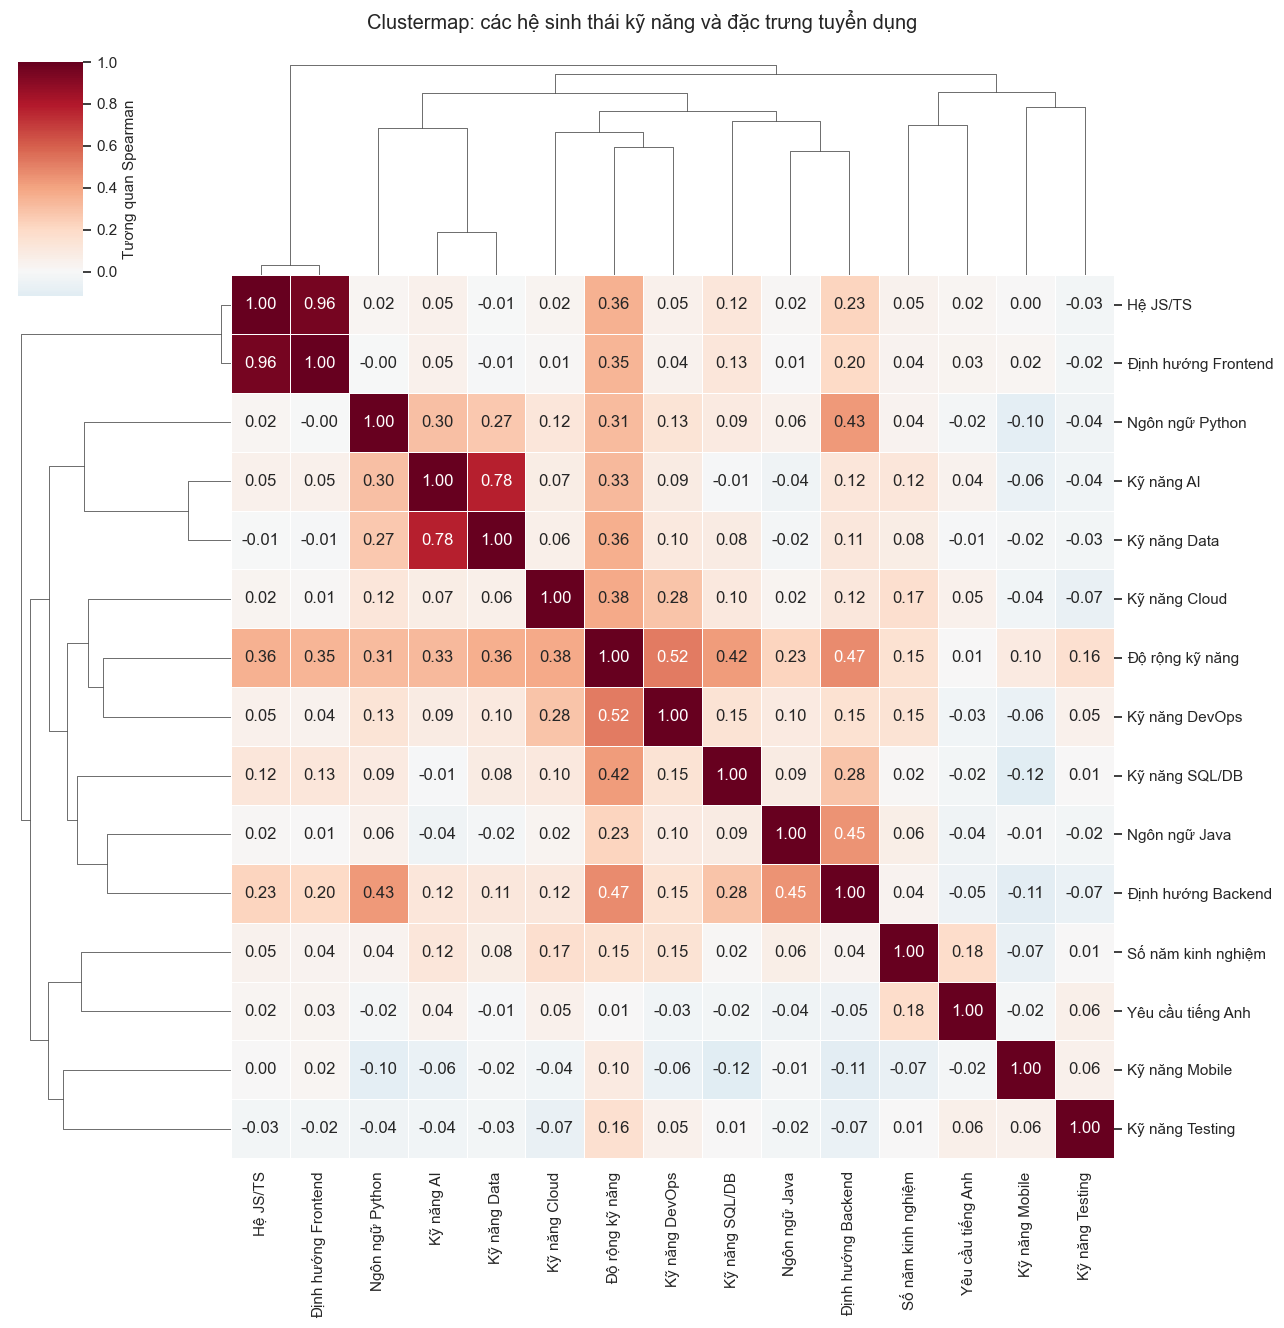

In [9]:
clustermap_data = corr_matrix_named.copy()

cluster_grid = sns.clustermap(
    clustermap_data,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    linecolor='white',
    figsize=(13, 13),
    cbar_kws={'label': 'Tương quan Spearman'},
)
cluster_grid.fig.suptitle('Clustermap: các hệ sinh thái kỹ năng và đặc trưng tuyển dụng', y=1.02)
plt.show()


### Clustermap
Clustermap là phiên bản giàu thông tin hơn heatmap thường vì nó **tự động sắp xếp và gom các biến có hành vi tương đồng lại gần nhau**.

Nhờ vậy, người xem không chỉ thấy từng cặp tương quan riêng lẻ mà còn nhìn ra các **cụm kỹ năng**. Ví dụ, nhóm **Hệ JS/TS** và **Định hướng Frontend** sẽ khác với nhóm **Ngôn ngữ Java**, **Kỹ năng SQL/DB**, **Định hướng Backend**.

**Nhận xét:** Từ clustermap, nhóm thấy dữ liệu có xu hướng chia ra thành vài nhóm khá dễ hiểu. Một nhóm gần với `web/frontend`, một nhóm gần với `backend - database`, và một nhóm gần với `Data/AI`. Như vậy, các feature hiện tại đã bắt đầu thể hiện được sự khác nhau giữa các mảng kỹ thuật, dù ranh giới giữa các nhóm chưa tách hoàn toàn.

**Nhận xét thêm:** Một số biến như `DevOps` và `Cloud` nằm ở vùng trung gian, tức là chúng có thể đi cùng nhiều nhóm khác nhau. Điều này cũng khá hợp lý vì trong thực tế các kỹ năng này thường không thuộc riêng một vai trò cố định.

**Liên hệ với biểu đồ vai trò và level:** Khi đối chiếu thêm với bảng chéo `job_title_group - level`, nhóm thấy các vai trò như `Back-end Developer` và `Full-stack Developer` trải đều từ `Junior` đến `Senior`, nên cụm của hai nhóm này thường khá rộng. Ngược lại, `Tech Lead` tập trung nhiều hơn ở `Lead` và `Senior`, nên trên không gian đặc trưng nhóm này dễ tách hơn nhờ vừa có khác biệt về kỹ năng vừa có khác biệt về level.


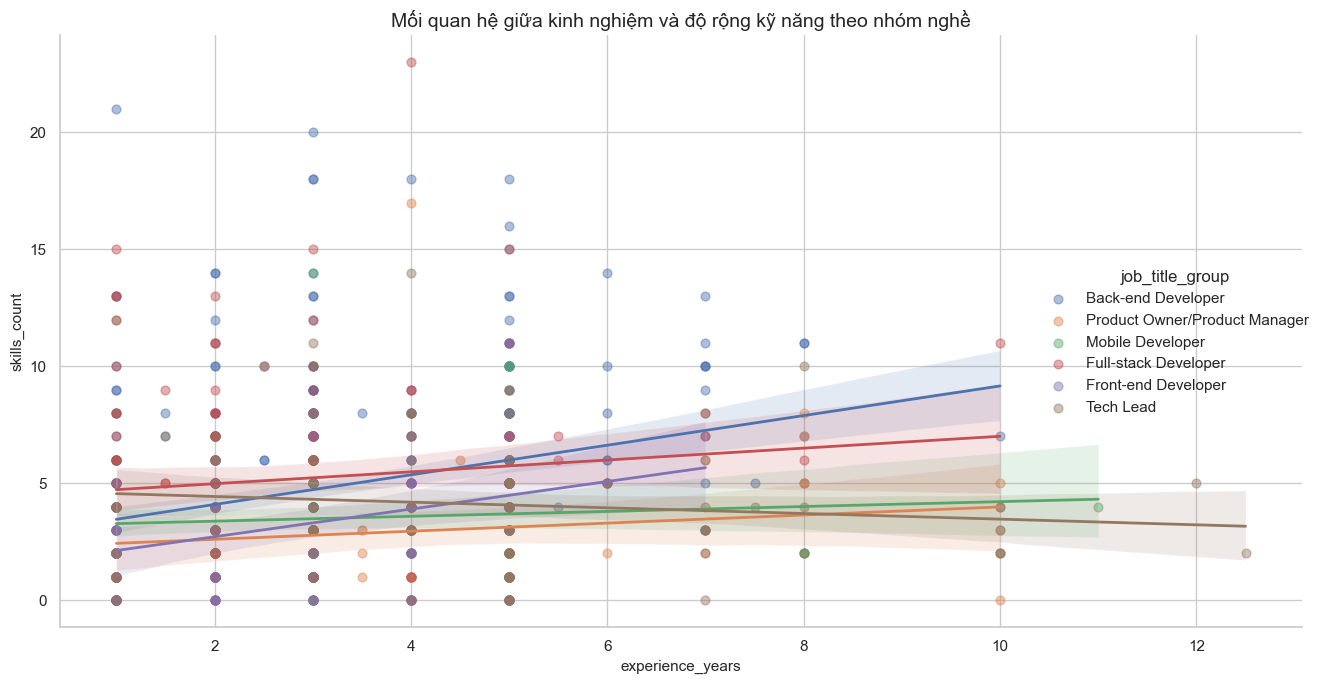

In [10]:
reg_df = df_features[
    ['experience_years', 'skills_count', 'job_title_group']
].dropna().copy()
reg_df = reg_df[reg_df['job_title_group'].isin(reg_df['job_title_group'].value_counts().head(6).index)]

sns.lmplot(
    data=reg_df,
    x='experience_years',
    y='skills_count',
    hue='job_title_group',
    height=7,
    aspect=1.5,
    scatter_kws={'alpha': 0.45, 's': 40},
    line_kws={'linewidth': 2},
    lowess=False,
)
plt.title('Mối quan hệ giữa kinh nghiệm và độ rộng kỹ năng theo nhóm nghề')
plt.tight_layout()
plt.show()


### LM Plot / Reg Plot
Biểu đồ này dùng `experience_years` trên trục X và `skills_count` trên trục Y, tô màu theo `job_title_group`.

Câu hỏi cần trả lời là: **càng nhiều kinh nghiệm thì số lượng kỹ năng yêu cầu có tăng lên hay không, hay sẽ bão hòa ở một mức nào đó?** Nếu từng nhóm nghề có độ dốc khác nhau, đó cũng là tín hiệu cho thấy dữ liệu có cấu trúc đa chiều chứ không đồng nhất.

**Nhận xét:** Nhóm thấy khi số năm kinh nghiệm tăng thì số lượng kỹ năng yêu cầu cũng có xu hướng tăng, nhưng mức tăng không quá mạnh. Hệ số tương quan Spearman giữa `experience_years` và `skills_count` chỉ khoảng `0.15`, tức là có quan hệ cùng chiều nhưng khá nhẹ.

**Nhận xét thêm:** Trung bình `skills_count` của nhóm `Senior` là khoảng `4.88`, cao hơn `Junior` (`3.64`) và `Intern/Fresher` (`3.27`). Từ đó có thể thấy kinh nghiệm vẫn có tác động đến yêu cầu kỹ năng, nhưng chưa phải yếu tố duy nhất quyết định cấu trúc dữ liệu.

**Liên hệ với clustermap:** Điều này giải thích vì sao trên các biểu đồ cụm, level và kỹ năng cần được xem cùng nhau. Có những nhóm như `Tech Lead` hoặc `Product Owner/Product Manager` không nhất thiết có một stack rất đặc trưng như frontend hay mobile, nhưng lại khác nhờ mức kinh nghiệm cao hơn và số lượng kỹ năng yêu cầu rộng hơn.


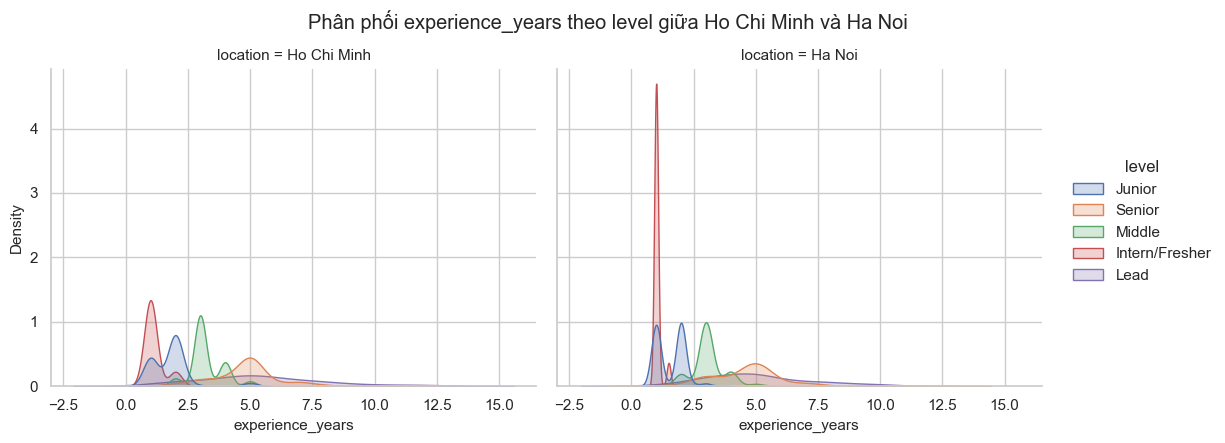

In [11]:
dist_df = df_clean[
    ['experience_years', 'level', 'location']
].dropna().copy()
dist_df = dist_df[dist_df['location'].isin(['Ho Chi Minh', 'Ha Noi'])]
dist_df = dist_df[dist_df['level'].isin(['Intern/Fresher', 'Junior', 'Middle', 'Senior', 'Lead'])]

g = sns.displot(
    data=dist_df,
    x='experience_years',
    col='location',
    hue='level',
    kind='kde',
    fill=True,
    common_norm=False,
    height=4.5,
    aspect=1.2,
)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle('Phân phối experience_years theo level giữa Ho Chi Minh và Ha Noi')
plt.show()


### Phân phối đa chiều
Biểu đồ phân phối theo `level` và `location` giúp so sánh cấu trúc tuyển dụng giữa các thành phố lớn, đặc biệt là `Ho Chi Minh` và `Ha Noi`.

Nếu phân bố `experience_years` khác nhau rõ theo `level` và theo `location`, điều đó cho thấy dữ liệu không đồng nhất ngẫu nhiên mà có cấu trúc thị trường tuyển dụng tương đối rõ.

**Nhận xét:** Nhìn vào phân phối giữa `Ho Chi Minh` và `Ha Noi`, nhóm thấy hai thành phố này có cấu trúc khá giống nhau ở các level chính như `Junior`, `Middle`, `Senior`, nhưng vẫn có một số khác biệt. `Ha Noi` có nhiều tin `Junior` hơn (`202` so với `141`), còn `Ho Chi Minh` có nhiều tin `Senior` hơn (`230` so với `116`).

**Nhận xét thêm:** Từ đó có thể thấy `location` không chỉ là biến mô tả cho đẹp mà thực sự có ý nghĩa trong việc phân biệt cấu trúc tuyển dụng giữa các khu vực.

**Liên hệ với nhóm kỹ năng:** Khi nhìn thêm theo `skill_domain`, `Ho Chi Minh` có số tin thuộc nhóm `Cloud/DevOps` và `Data/AI` khá cao, còn `Ha Noi` cũng mạnh nhưng phân bố cân hơn giữa `Backend`, `General` và `Data/AI`. Điều này cho thấy khác biệt giữa hai thành phố không chỉ nằm ở số lượng tin mà còn nằm ở cơ cấu kỹ năng tuyển dụng.


### Diễn giải tổng hợp
- Nếu heatmap và clustermap xuất hiện các cụm kỹ năng rõ, đó là tín hiệu tốt cho feature space.
- Nếu `experience_years` và `skills_count` có quan hệ tăng dần theo từng nhóm nghề, thì biến kinh nghiệm có giá trị phân biệt.
- Nếu phân phối theo `location` và `level` khác nhau rõ ràng, dữ liệu có khả năng hình thành các cụm tự nhiên theo vai trò và bối cảnh tuyển dụng.

**Nhận xét chung của nhóm:** Sau khi xem các biểu đồ đa biến, nhóm thấy dữ liệu đã bắt đầu thể hiện một số cấu trúc theo skill, level, location và vai trò công việc. Các nhóm như `web/frontend`, `backend/database`, `data/AI` đều xuất hiện lặp lại ở nhiều biểu đồ khác nhau. Vì vậy, nhóm cho rằng hướng phân cụm là phù hợp với bộ dữ liệu hiện tại.

**Nhận xét liên kết giữa các biểu đồ:** Các biểu đồ đang hỗ trợ nhau khá tốt. Heatmap cho thấy skill nào hay đi cùng nhau. Clustermap cho thấy các skill đó tạo thành nhóm lớn hơn. LM plot cho thấy level kinh nghiệm có liên quan tới độ rộng kỹ năng. Distribution plot cho thấy cùng một level nhưng mỗi thành phố có thể có cơ cấu khác nhau. Khi ghép các góc nhìn này lại, nhóm thấy dữ liệu có đủ dấu hiệu để tin rằng bên trong tồn tại các cụm nghề nghiệp và cụm công nghệ tương đối rõ, dù chưa tách hoàn toàn.


## 9. Trực quan hóa không gian dữ liệu nhiều chiều bằng t-SNE
Để trả lời câu hỏi **dữ liệu có phân cụm tự nhiên hay không**, notebook sử dụng `t-SNE` để giảm chiều không gian đặc trưng từ hơn 20 biến đã chọn về mặt phẳng 2D.

Trước khi chạy `t-SNE`, các biến category như `job_title_group`, `location`, `company_type`, `main_language`, `main_framework`, `skill_domain` được chuyển thành dạng số bằng **One-Hot Encoding**; còn các biến số và nhị phân được chuẩn hóa trước khi ghép vào không gian đặc trưng chung.

Để biểu đồ dễ nhìn hơn, các `job_title_group` có ít mẫu trong tập vẽ sẽ được gộp thành **Nhóm khác** thay vì hiển thị quá nhiều màu và quá nhiều nhãn trên legend.


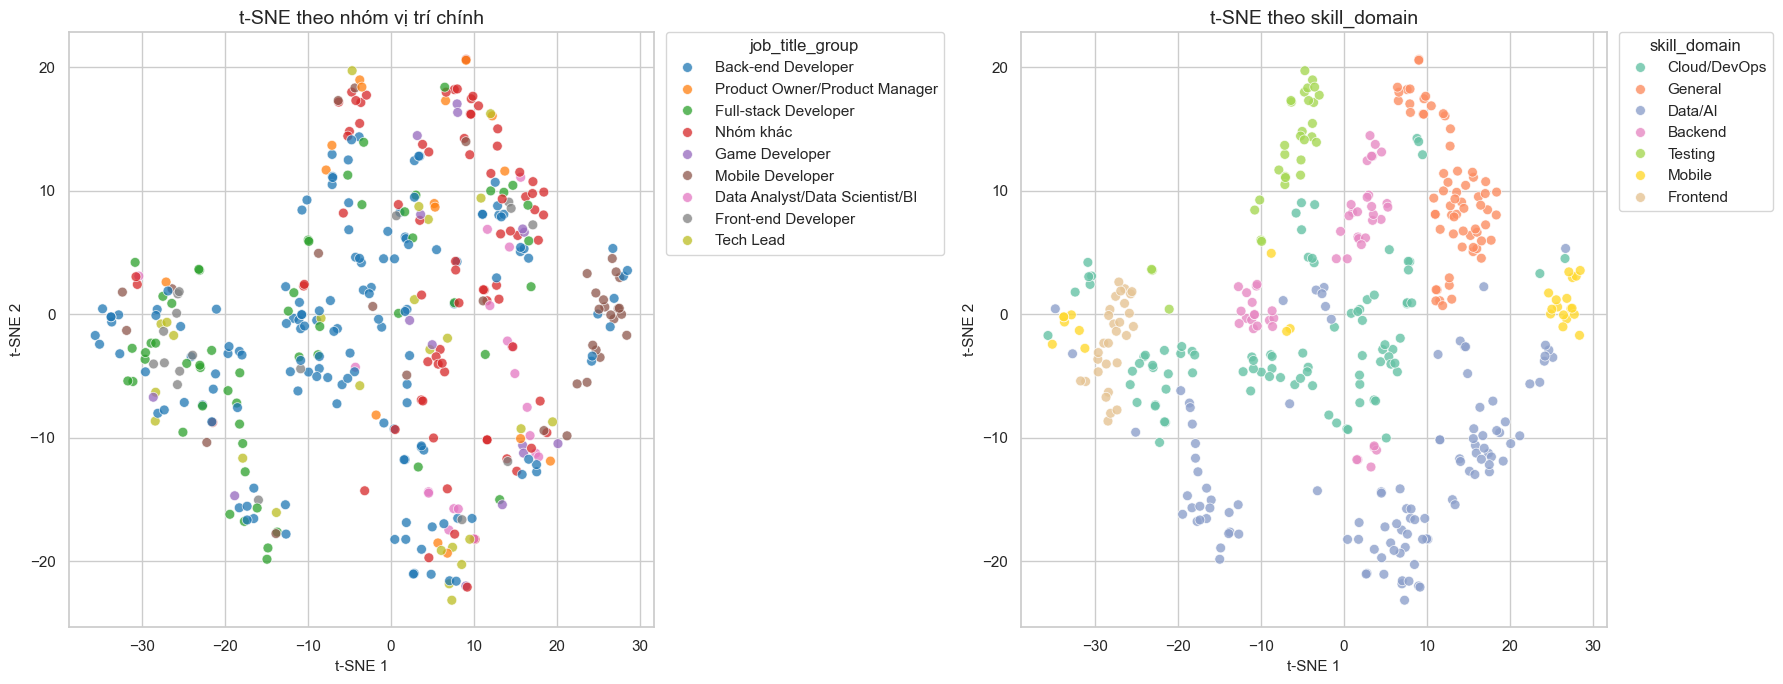

In [12]:
embedding_features = [
    'job_title_group', 'level', 'experience_years', 'location', 'company_type',
    'remote_option', 'skills_count', 'main_language', 'main_framework',
    'skill_domain', 'requires_english', 'has_ai', 'has_python', 'has_java',
    'has_js_ts', 'has_sql', 'has_cloud', 'has_data', 'has_devops',
    'has_mobile', 'has_testing', 'has_backend', 'has_frontend'
]

tsne_sample = df_features[embedding_features].copy()
if len(tsne_sample) > 400:
    tsne_sample = tsne_sample.sample(400, random_state=42)

categorical_cols = [
    'job_title_group', 'level', 'location', 'company_type', 'remote_option',
    'main_language', 'main_framework', 'skill_domain'
]
numeric_cols = [col for col in embedding_features if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('onehot', OneHotEncoder(handle_unknown='ignore')),
                ]
            ),
            categorical_cols,
        ),
        (
            'num',
            Pipeline(
                steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler()),
                ]
            ),
            numeric_cols,
        ),
    ]
)

X_embedded = preprocessor.fit_transform(tsne_sample[embedding_features])
if hasattr(X_embedded, 'toarray'):
    X_embedded = X_embedded.toarray()

perplexity = min(30, max(5, len(tsne_sample) // 15))
coords = TSNE(
    n_components=2,
    perplexity=perplexity,
    learning_rate='auto',
    init='pca',
    random_state=42,
).fit_transform(X_embedded)

tsne_plot_df = tsne_sample[['level', 'job_title_group', 'skill_domain']].copy()
tsne_plot_df['tsne_1'] = coords[:, 0]
tsne_plot_df['tsne_2'] = coords[:, 1]

top_roles_tsne = tsne_plot_df['job_title_group'].value_counts().head(8).index
tsne_plot_df['job_title_group_view'] = tsne_plot_df['job_title_group'].where(
    tsne_plot_df['job_title_group'].isin(top_roles_tsne),
    'Nhóm khác'
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.scatterplot(
    data=tsne_plot_df,
    x='tsne_1',
    y='tsne_2',
    hue='job_title_group_view',
    palette='tab10',
    alpha=0.75,
    s=50,
    ax=axes[0],
)
axes[0].set_title('t-SNE theo nhóm vị trí chính')
axes[0].legend(title='job_title_group', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

sns.scatterplot(
    data=tsne_plot_df,
    x='tsne_1',
    y='tsne_2',
    hue='skill_domain',
    palette='Set2',
    alpha=0.8,
    s=50,
    ax=axes[1],
)
axes[1].set_title('t-SNE theo skill_domain')
axes[1].legend(title='skill_domain', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

for ax in axes:
    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')

plt.tight_layout()
plt.show()


### Diễn giải t-SNE
- Nếu các điểm dữ liệu tạo thành các “đảo” riêng biệt, điều đó cho thấy bộ feature đã chọn có khả năng mô tả tốt các cụm nghề nghiệp/công nghệ.
- Ví dụ, cụm `Data/AI` có thể tách khỏi cụm `Testing` hoặc `Frontend`.
- Nếu các điểm trộn lẫn mạnh, điều đó hàm ý ranh giới giữa các vị trí đang mờ hơn hoặc bộ feature vẫn chưa đủ mạnh để tách cụm rõ ràng.

Trong bài giữa kỳ, `t-SNE` không nhằm thực hiện clustering chính thức mà đóng vai trò công cụ trực quan để đánh giá cấu trúc tự nhiên của không gian dữ liệu đầu vào.

**Nhận xét:** Với đề tài tuyển dụng IT, việc các điểm không tách hoàn toàn thành các cụm cứng là điều dễ hiểu, vì một tin tuyển dụng có thể vừa mang tính backend, vừa có cloud hoặc data. Trên biểu đồ t-SNE hiện tại, nhóm quan sát được một vài vùng tập trung, nhưng các vùng này vẫn còn chồng lấn ở khá nhiều chỗ.

**Nhận xét thêm:** Điều đó cho thấy bộ feature hiện tại đã có khả năng biểu diễn cấu trúc dữ liệu ở mức tương đối, đủ để thử hướng phân cụm, nhưng chưa thể tạo ra các cụm tách biệt hoàn toàn.

**Liên hệ với các biểu đồ trước:** Kết quả này khá khớp với heatmap và clustermap. Một số nhóm skill đi gần nhau như `has_ai - has_data` hay `has_js_ts - has_frontend` vẫn có thể tạo ra các vùng tập trung trên t-SNE. Tuy nhiên, do nhiều vị trí tuyển dụng hiện nay yêu cầu kỹ năng giao thoa giữa nhiều mảng nên việc các cụm còn chồng lấn cũng là điều hợp lý.


## 10. Khảo sát riêng tập con có lương
Ngoài hướng `clustering` trên toàn bộ dữ liệu sạch, nhóm tách riêng tập con `jobs_salary_subset.csv` để kiểm tra nhanh khả năng mở rộng sang bài toán `regression` với biến mục tiêu `salary_avg`.\n

Mục tiêu của phần này không phải xây dựng mô hình hoàn chỉnh, mà chỉ để trả lời xem trong tập con có lương có xuất hiện một số quy luật cơ bản giữa `salary_avg` với `level`, `location`, `job_title_group` và `experience_years` hay không.\n

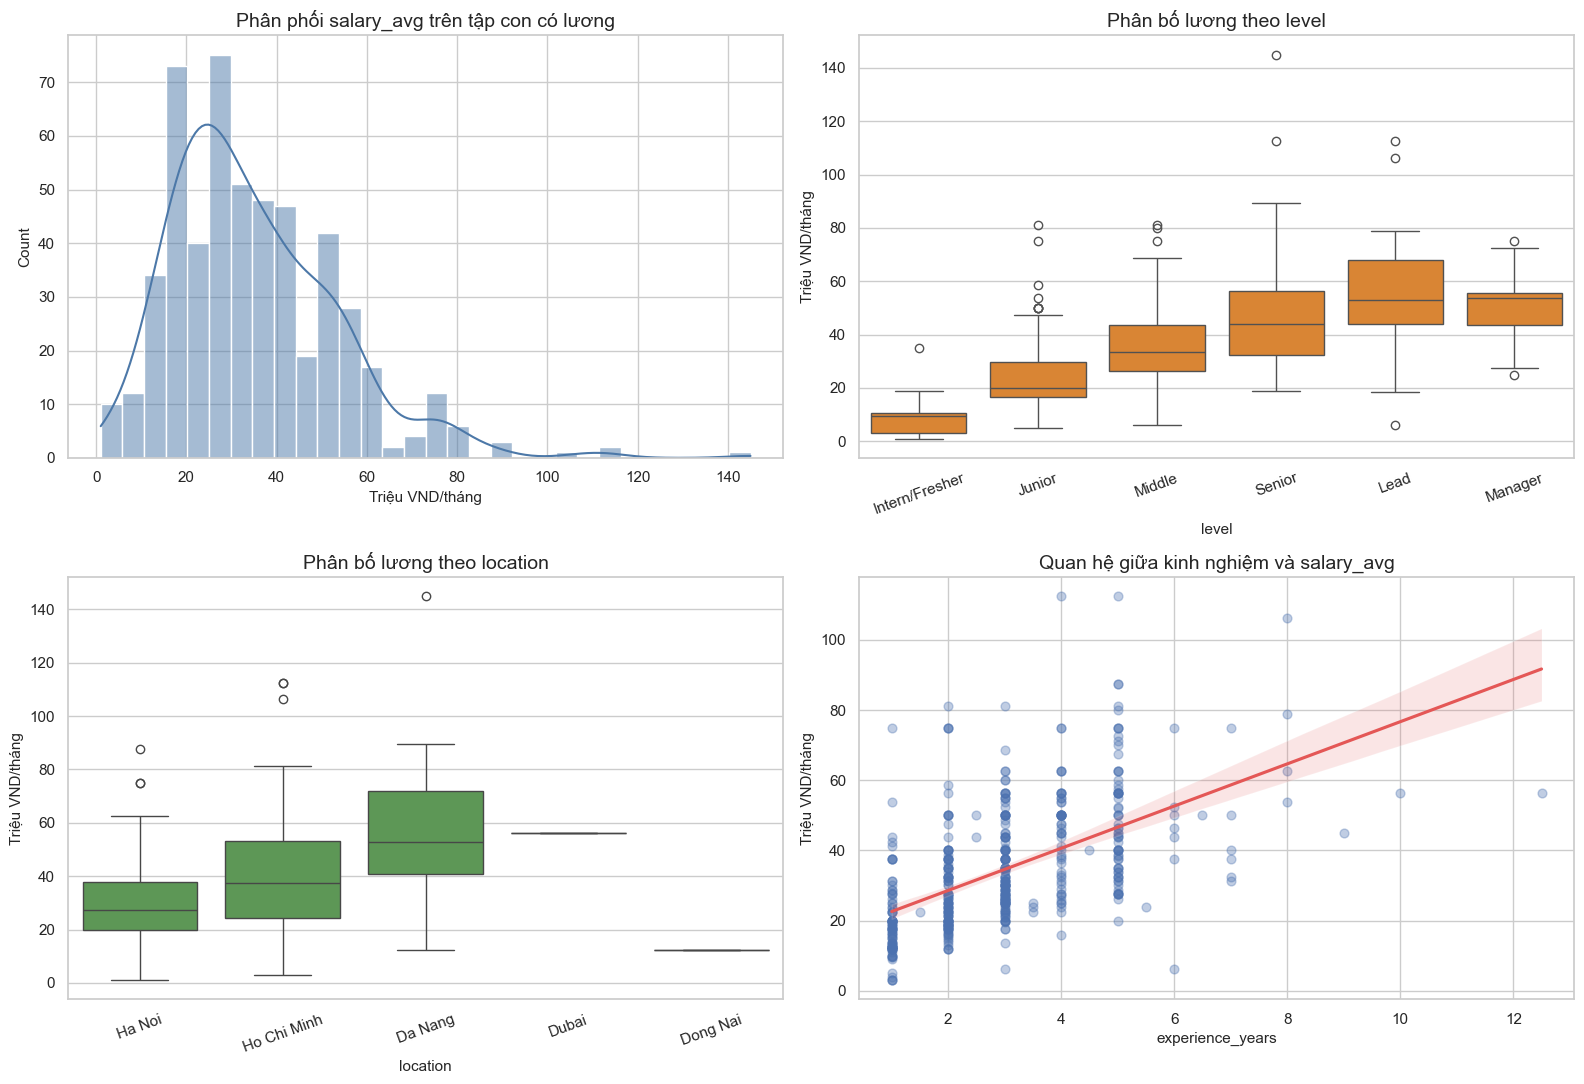

In [13]:
salary_viz = df_salary.copy()
salary_viz = salary_viz.dropna(subset=['salary_avg'])
salary_viz['salary_million_vnd'] = salary_viz['salary_avg'] / 1_000_000

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

sns.histplot(data=salary_viz, x='salary_million_vnd', bins=30, kde=True, ax=axes[0, 0], color='#4c78a8')
axes[0, 0].set_title('Phân phối salary_avg trên tập con có lương')
axes[0, 0].set_xlabel('Triệu VND/tháng')

level_order_salary = [lvl for lvl in ['Intern/Fresher', 'Junior', 'Middle', 'Senior', 'Lead', 'Manager'] if lvl in salary_viz['level'].dropna().unique()]
sns.boxplot(data=salary_viz, x='level', y='salary_million_vnd', order=level_order_salary, ax=axes[0, 1], color='#f58518')
axes[0, 1].set_title('Phân bố lương theo level')
axes[0, 1].set_xlabel('level')
axes[0, 1].set_ylabel('Triệu VND/tháng')
axes[0, 1].tick_params(axis='x', rotation=20)

top_salary_locations = salary_viz['location'].value_counts().head(5).index
sns.boxplot(data=salary_viz[salary_viz['location'].isin(top_salary_locations)], x='location', y='salary_million_vnd', ax=axes[1, 0], color='#54a24b')
axes[1, 0].set_title('Phân bố lương theo location')
axes[1, 0].set_xlabel('location')
axes[1, 0].set_ylabel('Triệu VND/tháng')
axes[1, 0].tick_params(axis='x', rotation=20)

sns.regplot(data=salary_viz, x='experience_years', y='salary_million_vnd', scatter_kws={'alpha': 0.35, 's': 40}, line_kws={'color': '#e45756'}, ax=axes[1, 1])
axes[1, 1].set_title('Quan hệ giữa kinh nghiệm và salary_avg')
axes[1, 1].set_xlabel('experience_years')
axes[1, 1].set_ylabel('Triệu VND/tháng')

plt.tight_layout()
plt.show()


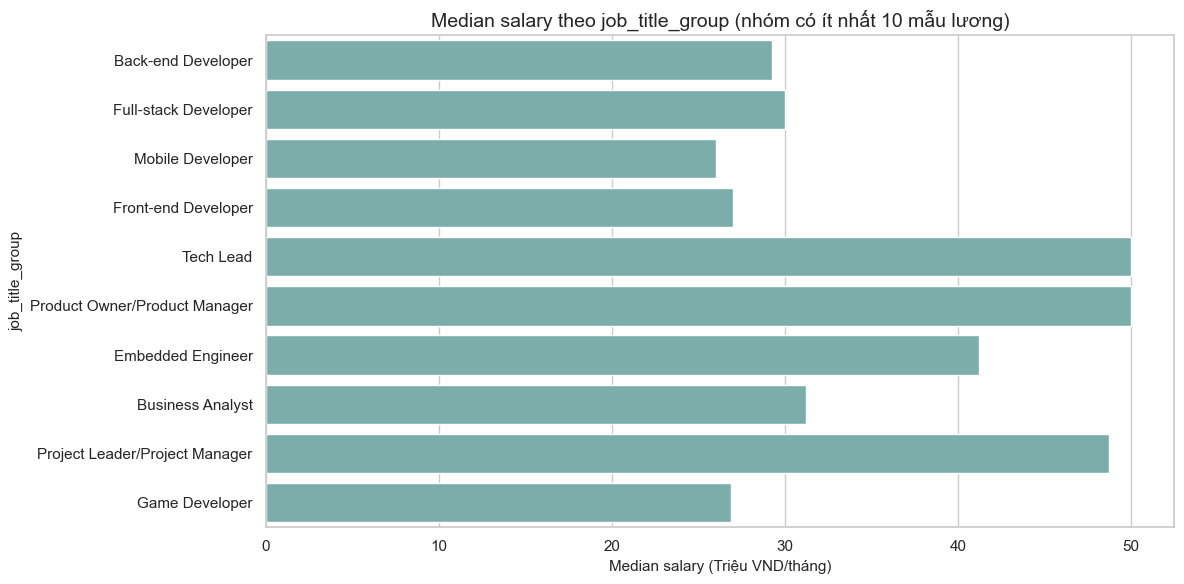

,job_title_group,count,median
0,Back-end Developer,206,29.250
1,Full-stack Developer,82,30.000
2,Mobile Developer,41,26.000
3,Front-end Developer,31,27.000
4,Tech Lead,30,50.000
5,Product Owner/Product Manager,23,50.000
6,Embedded Engineer,17,41.250
7,Business Analyst,14,31.250
8,Project Leader/Project Manager,12,48.750
9,Game Developer,12,26.875


In [14]:
salary_role = salary_viz.groupby('job_title_group')['salary_million_vnd'].agg(['count', 'median']).sort_values(by='count', ascending=False)
salary_role = salary_role[salary_role['count'] >= 10].head(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=salary_role, x='median', y='job_title_group', color='#72b7b2')
plt.title('Median salary theo job_title_group (nhóm có ít nhất 10 mẫu lương)')
plt.xlabel('Median salary (Triệu VND/tháng)')
plt.ylabel('job_title_group')
plt.tight_layout()
plt.show()

salary_role


### Nhận xét về tập con có lương
- Tập con có lương giúp nhóm kiểm tra nhanh xem `salary_avg` có biến động theo `level`, `location`, `experience_years` và `job_title_group` hay không.
- Nếu boxplot theo `level` cho thấy median lương tăng dần từ `Junior` lên `Senior/Lead`, thì đây là dấu hiệu tốt cho hướng hồi quy.
- Nếu `experience_years` và `salary_avg` có xu hướng cùng chiều, thì `experience_years` là một feature có ích cho bài toán phụ về lương.
- Tuy nhiên, do tập con này chỉ gồm các bản ghi có lương nên quy mô nhỏ hơn toàn bộ dữ liệu sạch. Vì vậy, nhóm chỉ dùng phần này để kiểm tra thêm khả năng làm `regression`, còn phần chính của bài vẫn là phân tích theo hướng `clustering`.

**Nhận xét:** Trên tập con có lương, nhóm thấy một số quy luật khá rõ. Median lương tăng dần theo `level`: `Intern/Fresher` khoảng `9.5`, `Junior` khoảng `20`, `Middle` khoảng `33.44`, `Senior` khoảng `43.88`, còn `Lead` và `Manager` đều trên `50` triệu. Như vậy, biến `level` có liên hệ khá rõ với `salary_avg`.

**Nhận xét thêm:** `experience_years` cũng có tương quan dương với lương, hệ số Spearman khoảng `0.62`, mạnh hơn nhiều so với tương quan giữa `experience_years` và `skills_count` ở phần clustering. Ngoài ra, một số nhóm như `Tech Lead` và `Product Owner/Product Manager` có median lương khoảng `50` triệu, cao hơn rõ so với `Back-end Developer` hay `Front-end Developer`. Điều này cho thấy nếu chỉ xét riêng tập con có lương thì hướng dự đoán `salary_avg` là có cơ sở, nhưng do số mẫu chỉ có `527` nên nhóm chỉ xem đây là phần khảo sát thêm.


## 10. Đánh giá tính khả thi của bài toán
### 10.1. Đối với hướng clustering (trọng tâm chính)
Bài toán **khả thi về mặt dữ liệu** vì:
- dữ liệu do nhóm tự crawl;
- số lượng mẫu raw `1415` > `1000`;
- số biến lớn hơn `5`;
- sau cleaning vẫn còn `1393` mẫu, đủ lớn cho EDA và quan sát cấu trúc cụm;
- đã có tập feature kết hợp category, numeric và NLP/binary skill indicators;
- có thể trực quan hóa được không gian nhiều chiều bằng `t-SNE`.

### 10.2. Đối với hướng salary regression (phần phụ)
Bài toán **vẫn có thể làm thử trên tập con có lương**, nhưng trong phạm vi bài giữa kỳ thì nhóm chỉ xem đây là phần khảo sát thêm vì:
- chỉ còn `527` mẫu có `salary_avg`;
- tỷ lệ thiếu lương trên tập clean còn cao;
- regression vì vậy phù hợp hơn như một baseline hoặc hướng phát triển ở bài tập tiếp theo.


In [15]:
feasibility_table = pd.DataFrame(
    [
        ['Tự thu thập dữ liệu', 'Đạt', 'Có crawler thực tế cho ITViec và TopCV'],
        ['Số lượng mẫu raw > 1000', 'Đạt', f'Tổng raw hiện có: {len(df_raw_merged)} mẫu'],
        ['Số lượng biến >= 5', 'Đạt', f'Raw data có từ {min(df_itviec.shape[1], df_topcv.shape[1])} đến {max(df_itviec.shape[1], df_topcv.shape[1])} biến'],
        ['Dữ liệu đủ sạch cho EDA/clustering', 'Đạt', f'Clean data còn {len(df_clean)} mẫu'],
        ['Có đặc trưng hữu ích cho clustering', 'Đạt', 'Có job group, level, location, company type, remote option, skill indicators, requires_english'],
        ['Có dữ liệu text để làm NLP', 'Đạt', 'Có tech_stack, job_title, job_description'],
        ['Regression trên salary có thể mở rộng', 'Khả thi ở mức phụ', f'Có {len(df_salary)} mẫu có salary_avg'],
        ['Rủi ro dữ liệu', 'Cần lưu ý', 'Thiếu salary nhiều; skill extraction vẫn có thể bỏ sót alias; dữ liệu lệch về 2 nguồn crawl'],
    ],
    columns=['Tiêu chí', 'Đánh giá', 'Giải thích'],
)
feasibility_table


,Tiêu chí,Đánh giá,Giải thích
0,Tự thu thập dữ liệu,Đạt,Có crawler thực tế cho ITViec và TopCV
1,Số lượng mẫu raw > 1000,Đạt,Tổng raw hiện có: 1415 mẫu
2,Số lượng biến >= 5,Đạt,Raw data có từ 12 đến 13 biến
3,Dữ liệu đủ sạch cho EDA/clustering,Đạt,Clean data còn 1393 mẫu
4,Có đặc trưng hữu ích cho clustering,Đạt,"Có job group, level, location, company type, r..."
5,Có dữ liệu text để làm NLP,Đạt,"Có tech_stack, job_title, job_description"
6,Regression trên salary có thể mở rộng,Khả thi ở mức phụ,Có 527 mẫu có salary_avg
7,Rủi ro dữ liệu,Cần lưu ý,Thiếu salary nhiều; skill extraction vẫn có th...


## 11. Kết luận
Kết luận chính của notebook là:
- **Hướng clustering / khám phá cấu trúc dữ liệu là phù hợp và khả thi hơn** trên bộ dữ liệu hiện tại.
- Bộ dữ liệu hiện có đủ lớn, đủ đa dạng và đủ giàu đặc trưng để phân tích theo `job_title_group`, `level`, `location`, `company_type`, `remote_option`, `skills_extracted` và `requires_english`.
- Cleaning, encoding và feature engineering hiện tại đã tạo ra một không gian đặc trưng có ý nghĩa cho việc trực quan hóa nhiều chiều và quan sát cụm.
- Phần `salary regression` được nhóm xem như một hướng phụ trên `jobs_salary_subset.csv`, vì số mẫu của tập này nhỏ hơn khá nhiều so với toàn bộ dữ liệu sạch.

Vì vậy, nếu bám sát yêu cầu giữa kỳ về đánh giá tính khả thi của bài toán bằng dữ liệu, nhóm có thể kết luận rằng:
- bài toán **clustering là khả thi**;
- tập đặc trưng hữu ích gồm `job_title_group`, `level`, `experience_years`, `location`, `company_type`, `remote_option`, `skills_extracted`, `skills_count`, `requires_english` và các biến chỉ báo kỹ năng;
- regression theo lương có thể được triển khai sau như một nhánh mở rộng trên tập con có lương.


## 12. Tài liệu tham khảo
- `src/data_collection/itviec_crawler.py`
- `src/data_collection/topcv_crawler.py`
- `src/processing/clean_jobs.py`
- `src/processing/extract_skills.py`
- `data/raw/itviec_jobs_20260316_190527.csv`
- `data/raw/topcv_jobs_20260316_205315.csv`
- `data/clean-data/jobs_cleaned.csv`
- `data/clean-data/jobs_features.csv`
- `data/clean-data/jobs_salary_subset.csv`
- Tài liệu tham khảo về feature engineering: <https://phamdinhkhanh.github.io/2019/01/07/Ky_thuat_feature_engineering.html>
- Tài liệu tham khảo về t-SNE: <https://www.datacamp.com/tutorial/introduction-t-sne>
